
Model Performance Metrics (Diabetes Dataset - 50K Sample):

Logistic Regression
  Accuracy: 0.8485
  Precision: 0.5574
  Recall: 0.1878
  F1: 0.2810
  ROC-AUC: 0.8133

Elastic Net Logistic
  Accuracy: 0.8484
  Precision: 0.5566
  Recall: 0.1872
  F1: 0.2802
  ROC-AUC: 0.8133

Random Forest
  Accuracy: 0.8440
  Precision: 0.5157
  Recall: 0.1662
  F1: 0.2514
  ROC-AUC: 0.7855

Gradient Boosting
  Accuracy: 0.8503
  Precision: 0.5750
  Recall: 0.1923
  F1: 0.2882
  ROC-AUC: 0.8169



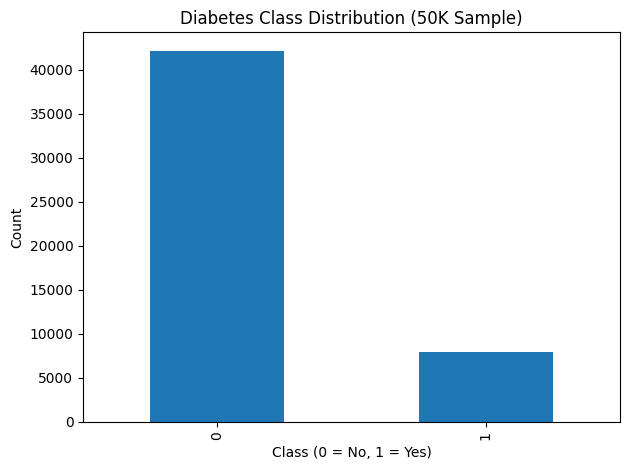

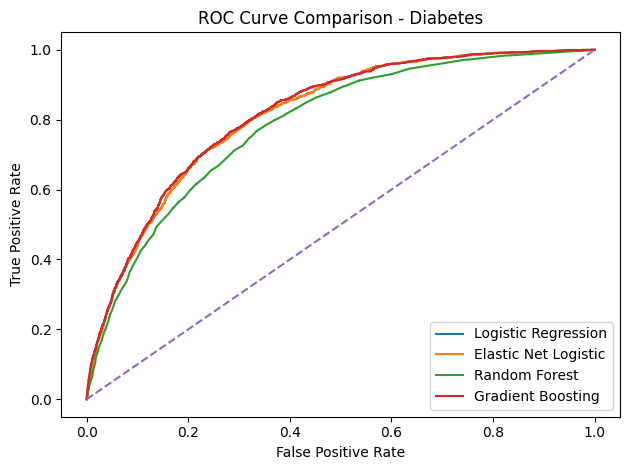

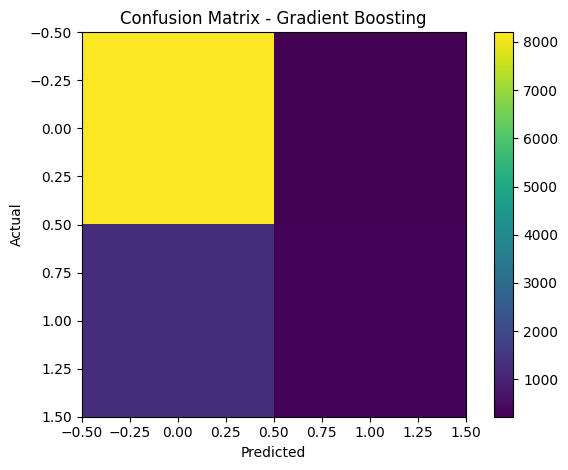

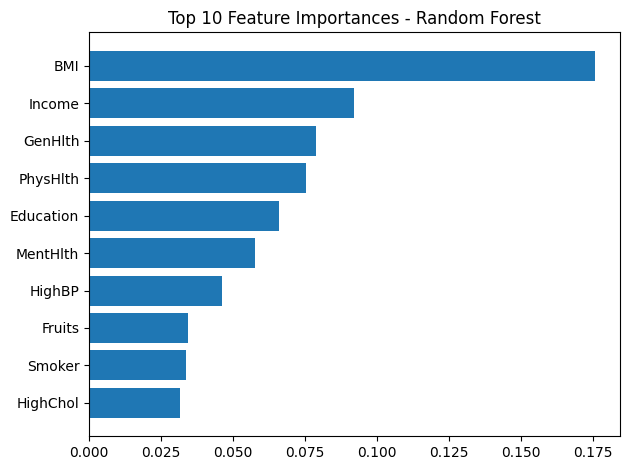

In [1]:
# ============================
# CAPSTONE MODELING PIPELINE
# Diabetes Dataset (cleaned_diabetes.csv)
# Models + Metrics + Figures
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

# ----------------------------
# 1) Load Data
# ----------------------------
df_full = pd.read_csv("C:\\Users\\eleat\\OneDrive\\Documents\\GitHub\\Module-B-semester-2-main\\Module-B-semester-2-main\\cleaned_diabetes.csv")  # <-- update path if needed

# Target in this file is Diabetes_012 (0 = none, 1 = pre, 2 = diabetes)
# Convert to binary: 0 = no diabetes, 1 = pre/diabetes
df_full["Diabetes_binary"] = (df_full["Diabetes_012"] > 0).astype(int)

# ----------------------------
# 2) Stratified Sample (50K)
# ----------------------------
# (This makes it run fast while keeping class distribution stable.)
df_small, _ = train_test_split(
    df_full,
    train_size=50000,
    stratify=df_full["Diabetes_binary"],
    random_state=42
)

X = df_small.drop(columns=["Diabetes_012", "Diabetes_binary"])
y = df_small["Diabetes_binary"]

# ----------------------------
# 3) Train/Test Split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ----------------------------
# 4) Define Models
# ----------------------------
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=500))
    ]),
    "Elastic Net Logistic": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            l1_ratio=0.5,
            max_iter=1000
        ))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    )
}

# ----------------------------
# 5) Train + Evaluate
# ----------------------------
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

# Print results nicely
print("\nModel Performance Metrics (Diabetes Dataset - 50K Sample):\n")
for model_name, metrics in results.items():
    print(model_name)
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")
    print()

# ----------------------------
# 6) Figure 1: Class Balance
# ----------------------------
plt.figure()
y.value_counts().plot(kind="bar")
plt.title("Diabetes Class Distribution (50K Sample)")
plt.xlabel("Class (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# ----------------------------
# 7) Figure 2: ROC Curve Comparison
# ----------------------------
plt.figure()
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Diabetes")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# 8) Figure 3: Confusion Matrix (Best Model by ROC-AUC)
# ----------------------------
best_model_name = max(results, key=lambda x: results[x]["ROC-AUC"])
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure()
plt.imshow(cm)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.tight_layout()
plt.show()

# ----------------------------
# 9) Figure 4: Feature Importances (Random Forest)
# ----------------------------
rf = models["Random Forest"]
importances = rf.feature_importances_

top_n = 10
indices = np.argsort(importances)[-top_n:]

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.title("Top 10 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

Sample unique target values: ['High' 'Low']

Final target distribution:
Hypertension
1    125781
0     49201
Name: count, dtype: int64

Model Performance Metrics (Hypertension - sample):

Logistic Regression
  Accuracy: 0.7188
  Precision: 0.7188
  Recall: 1.0000
  F1: 0.8364
  ROC-AUC: 0.4840

Elastic Net Logistic
  Accuracy: 0.7188
  Precision: 0.7188
  Recall: 1.0000
  F1: 0.8364
  ROC-AUC: 0.4842

Random Forest
  Accuracy: 0.7188
  Precision: 0.7188
  Recall: 1.0000
  F1: 0.8364
  ROC-AUC: 0.4863

Gradient Boosting
  Accuracy: 0.7187
  Precision: 0.7188
  Recall: 0.9999
  F1: 0.8363
  ROC-AUC: 0.4956



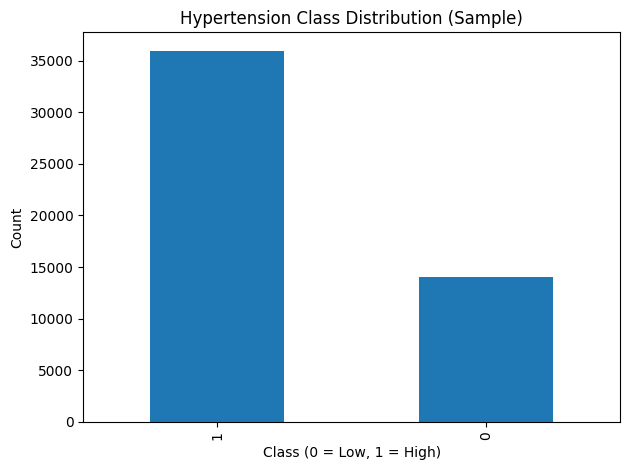

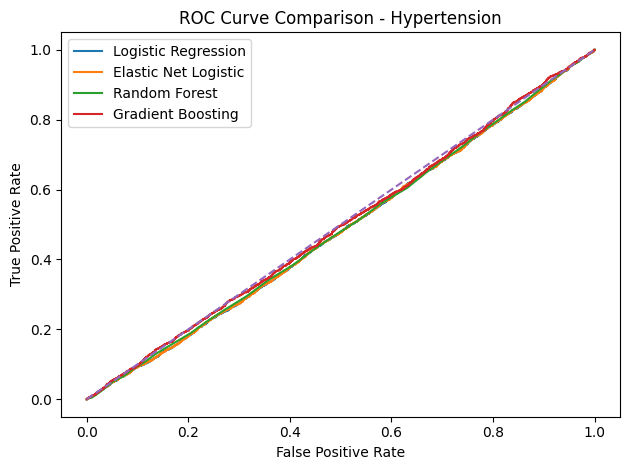

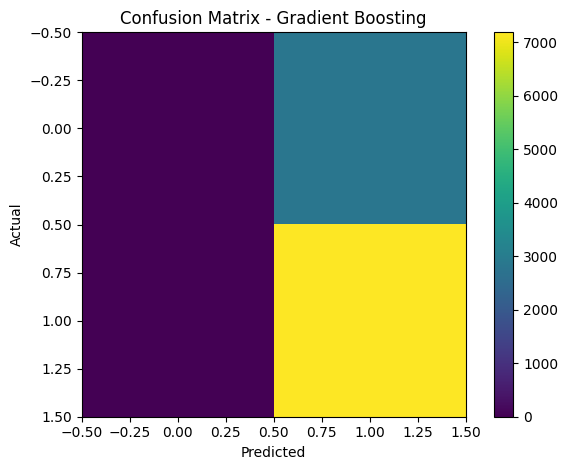

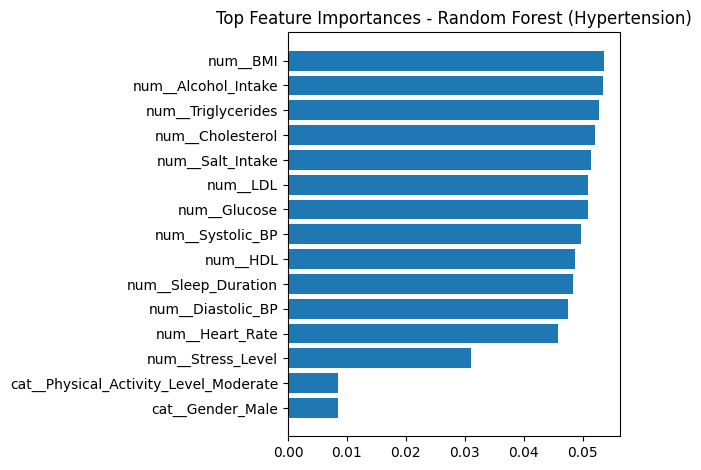

In [4]:
# ============================
# CAPSTONE MODELING PIPELINE
# Hypertension Dataset (cleaned_hypertension.csv)
# Models + Metrics + Figures
# (Fixed for target values: High / Low)
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)

# ----------------------------
# 1) Load Data
# ----------------------------
df_full = pd.read_csv("C:\\Users\\eleat\\OneDrive\\Documents\\GitHub\\Module-B-semester-2-main\\Module-B-semester-2-main\\cleaned_hypertension.csv")  # <-- update path if needed
target_col = "Hypertension"

print("Sample unique target values:", df_full[target_col].dropna().unique()[:20])

# ----------------------------
# 2) Robust Target Conversion
#    (Handles numeric, yes/no, and high/low)
# ----------------------------
y_numeric = pd.to_numeric(df_full[target_col], errors="coerce")

if y_numeric.notna().mean() > 0.95:
    df_full[target_col] = y_numeric
else:
    s = df_full[target_col].astype(str).str.strip().str.lower()
    df_full[target_col] = s.map({
        # yes/no style
        "yes": 1, "y": 1, "true": 1, "1": 1,
        "no": 0, "n": 0, "false": 0, "0": 0,

        # high/low style (YOUR DATASET)
        "high": 1,
        "low": 0
    })

# Drop only rows where target could not be interpreted
df_full = df_full.dropna(subset=[target_col])

# Final type
df_full[target_col] = df_full[target_col].astype(int)

print("\nFinal target distribution:")
print(df_full[target_col].value_counts())

# Safety check
if len(df_full) < 100:
    raise ValueError(
        f"After target cleaning, dataset has only {len(df_full)} rows. "
        "That means the target mapping likely missed values. "
        "Print unique target values again and expand mapping."
    )

# ----------------------------
# 3) Stratified Sample (optional)
# ----------------------------
sample_n = 50000
train_size = min(sample_n, len(df_full))

# If dataset is smaller than sample_n, just use full dataset
if train_size == len(df_full):
    df_small = df_full.copy()
else:
    df_small, _ = train_test_split(
        df_full,
        train_size=train_size,
        stratify=df_full[target_col],
        random_state=42
    )

X = df_small.drop(columns=[target_col])
y = df_small[target_col]

# ----------------------------
# 4) Train/Test Split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ----------------------------
# 5) Preprocessing
# ----------------------------
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder="drop"
)

# ----------------------------
# 6) Define Models
# ----------------------------
models = {
    "Logistic Regression": Pipeline([
        ("prep", preprocess),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    "Elastic Net Logistic": Pipeline([
        ("prep", preprocess),
        ("model", LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            l1_ratio=0.5,
            max_iter=2000
        ))
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocess),
        ("model", RandomForestClassifier(n_estimators=200, random_state=42))
    ]),
    "Gradient Boosting": Pipeline([
        ("prep", preprocess),
        ("model", GradientBoostingClassifier(n_estimators=150, random_state=42))
    ])
}

# ----------------------------
# 7) Train + Evaluate
# ----------------------------
results = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

print("\nModel Performance Metrics (Hypertension - sample):\n")
for model_name, metrics in results.items():
    print(model_name)
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")
    print()

# ----------------------------
# Figure 1: Class Balance
# ----------------------------
plt.figure()
y.value_counts().plot(kind="bar")
plt.title("Hypertension Class Distribution (Sample)")
plt.xlabel("Class (0 = Low, 1 = High)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# ----------------------------
# Figure 2: ROC Curve Comparison
# ----------------------------
plt.figure()
for name, pipe in models.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Hypertension")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# Figure 3: Confusion Matrix (Best Model by ROC-AUC)
# ----------------------------
best_model_name = max(results, key=lambda x: results[x]["ROC-AUC"])
best_pipe = models[best_model_name]

y_pred_best = best_pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure()
plt.imshow(cm)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.tight_layout()
plt.show()

# ----------------------------
# Figure 4: Feature Importance (Random Forest)
# ----------------------------
rf_pipe = models["Random Forest"]
rf_model = rf_pipe.named_steps["model"]
prep = rf_pipe.named_steps["prep"]

feature_names = prep.get_feature_names_out()
importances = rf_model.feature_importances_

top_n = 15
idx = np.argsort(importances)[-top_n:]

plt.figure()
plt.barh(range(len(idx)), importances[idx])
plt.yticks(range(len(idx)), feature_names[idx])
plt.title("Top Feature Importances - Random Forest (Hypertension)")
plt.tight_layout()
plt.show()

Final target distribution:
PreviousAcuteKidneyInjury
0    1484
1     175
Name: count, dtype: int64


s:\Programming\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Model Performance Metrics (Kidney Dataset):

Logistic Regression
  Accuracy: 0.5964
  Precision: 0.0840
  Recall: 0.2857
  F1: 0.1299
  ROC-AUC: 0.4924

Elastic Net Logistic
  Accuracy: 0.5783
  Precision: 0.0992
  Recall: 0.3714
  F1: 0.1566
  ROC-AUC: 0.4849

Random Forest
  Accuracy: 0.8946
  Precision: 0.0000
  Recall: 0.0000
  F1: 0.0000
  ROC-AUC: 0.5519

Gradient Boosting
  Accuracy: 0.8855
  Precision: 0.0000
  Recall: 0.0000
  F1: 0.0000
  ROC-AUC: 0.4827



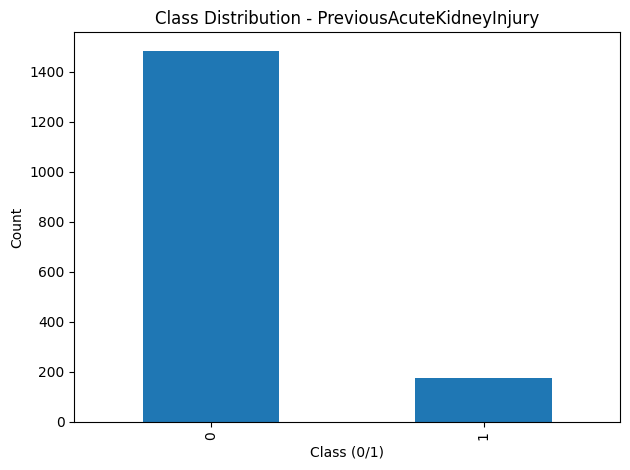

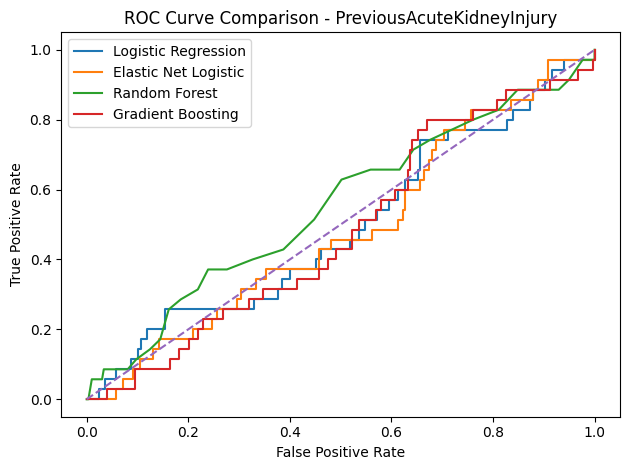

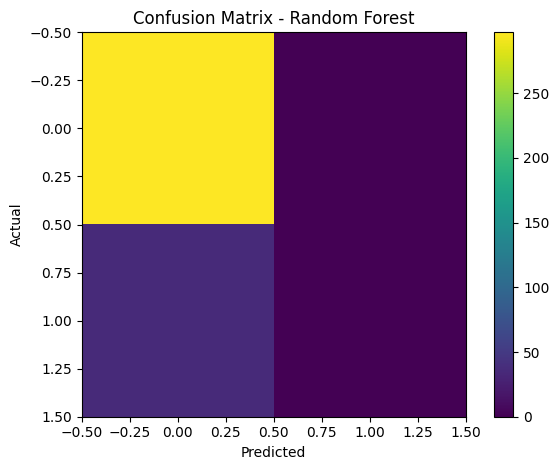

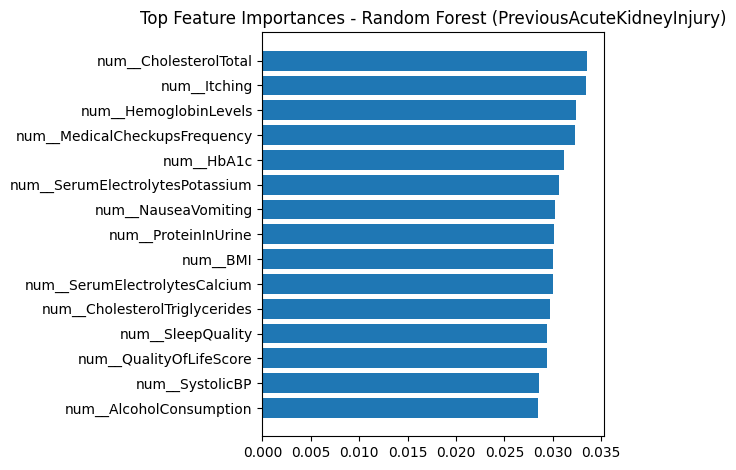

In [8]:
df_full = pd.read_csv("C:\\Users\\eleat\\OneDrive\\Documents\\GitHub\\Module-B-semester-2-main\\Module-B-semester-2-main\\cleaned_kidney.csv")  # <-- update path if needed

# ✅ Choose your target (pick ONE)
target_col = "PreviousAcuteKidneyInjury"
# target_col = "FamilyHistoryKidneyDisease"

# ----------------------------
# 2) Clean Target + Drop obvious ID columns
# ----------------------------
# Ensure target is numeric 0/1
df_full[target_col] = pd.to_numeric(df_full[target_col], errors="coerce")
df_full = df_full.dropna(subset=[target_col])
df_full[target_col] = df_full[target_col].astype(int)

# Drop ID-like columns if present (helps prevent leakage)
drop_cols = [c for c in ["PatientID", "DoctorInCharge"] if c in df_full.columns]
df_full = df_full.drop(columns=drop_cols)

print("Final target distribution:")
print(df_full[target_col].value_counts())

# Safety check
if df_full[target_col].nunique() < 2:
    raise ValueError("Target column has only one class. Choose a different target or check the dataset.")

# ----------------------------
# 3) Train/Test Split
# ----------------------------
X = df_full.drop(columns=[target_col])
y = df_full[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ----------------------------
# 4) Preprocessing (numeric + categorical)
# ----------------------------
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder="drop"
)

# ----------------------------
# 5) Define Models
# ----------------------------
models = {
    "Logistic Regression": Pipeline([
        ("prep", preprocess),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]),
    "Elastic Net Logistic": Pipeline([
        ("prep", preprocess),
        ("model", LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            l1_ratio=0.5,
            max_iter=2000,
            class_weight="balanced"
        ))
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocess),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        ))
    ]),
    "Gradient Boosting": Pipeline([
        ("prep", preprocess),
        ("model", GradientBoostingClassifier(
            n_estimators=150,
            random_state=42
        ))
    ])
}

# ----------------------------
# 6) Train + Evaluate
# ----------------------------
results = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

print("\nModel Performance Metrics (Kidney Dataset):\n")
for model_name, metrics in results.items():
    print(model_name)
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")
    print()

# ----------------------------
# Figure 1: Class Balance
# ----------------------------
plt.figure()
y.value_counts().plot(kind="bar")
plt.title(f"Class Distribution - {target_col}")
plt.xlabel("Class (0/1)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# ----------------------------
# Figure 2: ROC Curve Comparison
# ----------------------------
plt.figure()
for name, pipe in models.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve Comparison - {target_col}")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# Figure 3: Confusion Matrix (Best Model by ROC-AUC)
# ----------------------------
best_model_name = max(results, key=lambda x: results[x]["ROC-AUC"])
best_pipe = models[best_model_name]

y_pred_best = best_pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure()
plt.imshow(cm)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.tight_layout()
plt.show()

# ----------------------------
# Figure 4: Feature Importance (Random Forest)
# ----------------------------
rf_pipe = models["Random Forest"]
rf_model = rf_pipe.named_steps["model"]
prep = rf_pipe.named_steps["prep"]

feature_names = prep.get_feature_names_out()
importances = rf_model.feature_importances_

top_n = 15
idx = np.argsort(importances)[-top_n:]

plt.figure()
plt.barh(range(len(idx)), importances[idx])
plt.yticks(range(len(idx)), feature_names[idx])
plt.title(f"Top Feature Importances - Random Forest ({target_col})")
plt.tight_layout()
plt.show()